# **STEP 1 — Install All Libraries**

In [65]:
!pip install yfinance          # for stock data
!pip install prophet           # for forecasting
!pip install vaderSentiment    # for sentiment analysis
!pip install plotly            # for interactive charts
!pip install pandas numpy matplotlib seaborn  # core libraries

print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


# **STEP 2 — Import All Libraries**

In [66]:
# Data handling
import pandas as pd
import numpy as np

# Charts
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

# Stock data
import yfinance as yf

# Date handling
from datetime import datetime, timedelta

# Warnings (hide unnecessary warning messages)
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# **STEP 3 — Download Stock Data**

In [67]:
# List of 5 stocks we want to analyze
# These are called "ticker symbols" — short codes for each company
#stocks = {"AAPL": "Apple", "AMZN": "Amazon", "TSLA": "Tesla", "MSFT": "Microsoft", "GOOGL": "Google"}

import yfinance as yf
from google.colab import files

# All 4 stocks
stocks = ["AAPL", "TSLA", "GOOGL", "MSFT" , "AMZN"]

# Download and save each stock
for ticker in stocks:
    print(f"Downloading {ticker}...")
    df = yf.download(ticker, start="2021-01-01", end="2026-04-30")
    df.to_csv(f"{ticker}_stock_data.csv")
    print(f" {ticker} saved — {len(df)} rows")

print("\n All 5 stocks saved!")

# Download all files to your computer
print("\n Downloading to your computer now...")
for ticker in stocks:
    files.download(f"{ticker}_stock_data.csv")
    print(f" {ticker}_stock_data.csv downloading...")

print("\n Done! Check Downloads folder!")

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed

 AAPL saved — 1336 rows



[*********************100%***********************]  1 of 1 completed

 TSLA saved — 1336 rows


...

<IPython.core.display.Javascript object>

 MSFT_stock_data.csv downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 AMZN_stock_data.csv downloading...

 Done! Check Downloads folder!


In [68]:
# Choose stock
ticker = "AAPL"

# Download data
df = yf.download(ticker, start="2021-01-01", end="2026-04-30")

# Show first 5 rows
print(f" Downloaded {len(df)} rows of data for {ticker}")
print("\n First 5 rows of data:")
print(df.head())

print("\n Last 5 rows of data:")
print(df.tail())

print("\n Shape of data (rows, columns):")
print(df.shape)

[*********************100%***********************]  1 of 1 completed

 Downloaded 1336 rows of data for AAPL

 First 5 rows of data:
Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-01-04  125.740845  129.821759  123.165979  129.734315  143301900
2021-01-05  127.295441  128.004754  124.788590  125.235554   97664900
2021-01-06  123.010521  127.334355  122.796757  124.098768  155088000
2021-01-07  127.208038  127.897914  124.234801  124.720624  109578200
2021-01-08  128.306000  128.869557  126.537595  128.675216  105158200

 Last 5 rows of data:
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2026-04-23  273.178314  275.516157  271.399954  274.796818  33399600
2026-04-24  270.810486  272.808645  269.401780  272.508933  38157100
2026-04-2

# **STEP 4 — Understand Data**

In [69]:
# -----------------------------------------------
# STEP 4A — Check basic information
# -----------------------------------------------

print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)

# How many rows and columns
print(f"\n Total rows: {len(df)}")
print(f" Total columns: {len(df.columns)}")

# Column names
print(f"\n Column names: {list(df.columns)}")

# Data types of each column
print("\n Data types:")
print(df.dtypes)

# -----------------------------------------------
# STEP 4B — Check for missing values
# -----------------------------------------------
print("\n Missing values in each column:")
print(df.isnull().sum())
# If all show 0, your data is clean!

# -----------------------------------------------
# STEP 4C — Basic statistics
# -----------------------------------------------
print("\n Basic Statistics:")
print(df.describe())
# This shows: count, mean, min, max, etc. for each column

DATASET INFORMATION

 Total rows: 1336
 Total columns: 5

 Column names: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]

 Data types:
Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

 Missing values in each column:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

 Basic Statistics:
Price         Close         High          Low         Open        Volume
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL
count   1336.000000  1336.000000  1336.000000  1336.000000  1.336000e+03
mean     184.164230   185.988258   182.172652   184.002145  6.838557e+07
std       43.464963    43.767213    43.129439    43.450641  2.980040e+07
min      113.229797   117.161125   113.083831   115.827976  1.791060e+07
25%      147.090405   148.339561   145.198

# **STEP 5 — Clean the Data**

In [70]:
# -----------------------------------------------
# Reset index so Date becomes a regular column
# -----------------------------------------------
df = df.reset_index()

# Make sure Date column is in date format
df["Date"] = pd.to_datetime(df["Date"])

# Set Date as index again (needed for time series)
df = df.set_index("Date")

# Drop any missing rows (if any)
df = df.dropna()

# Flatten multi-level columns if present (yfinance sometimes creates them)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print("Data cleaned successfully!")
print(df.head())

Data cleaned successfully!
Price            Close        High         Low        Open     Volume
Date                                                                 
2021-01-04  125.740845  129.821759  123.165979  129.734315  143301900
2021-01-05  127.295441  128.004754  124.788590  125.235554   97664900
2021-01-06  123.010521  127.334355  122.796757  124.098768  155088000
2021-01-07  127.208038  127.897914  124.234801  124.720624  109578200
2021-01-08  128.306000  128.869557  126.537595  128.675216  105158200


# **STEP 6 — Draw Basic Charts**

***Chart 1 — Closing Price Over Time***

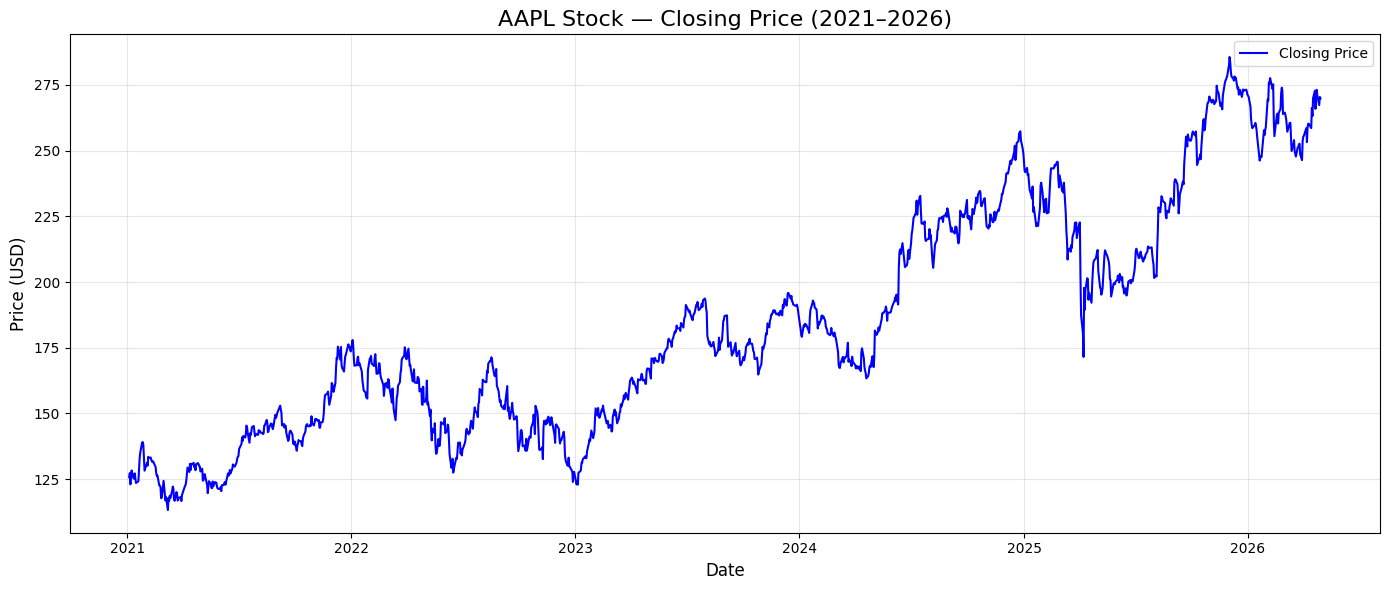

This chart shows the overall price trend of the stock


In [71]:
# -----------------------------------------------
# This chart shows how the stock price changed
# over the years — going up or down
# -----------------------------------------------

plt.figure(figsize=(14, 6))   # size of the chart (width, height)

plt.plot(df.index,             # x-axis = dates
         df["Close"],          # y-axis = closing price
         color="blue",
         linewidth=1.5,
         label="Closing Price")

plt.title(f"{ticker} Stock — Closing Price (2021–2026)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("This chart shows the overall price trend of the stock")

***Chart 2 — Trading Volume***

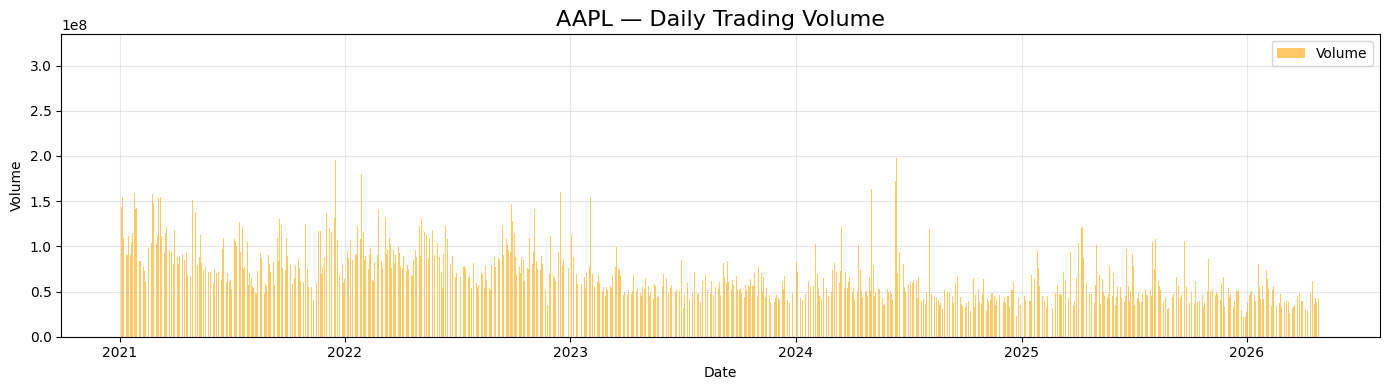

In [75]:
# -----------------------------------------------
# Volume = how many shares were traded each day
# High volume = lots of interest in the stock
# -----------------------------------------------

import matplotlib.dates as mdates # Import for date conversion

plt.figure(figsize=(14, 4))

plt.bar(df.index,
        df["Volume"],
        color="orange",
        alpha=0.6,
        label="Volume")

plt.title(f"{ticker} — Daily Trading Volume", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

***Chart 3 — Daily Returns***

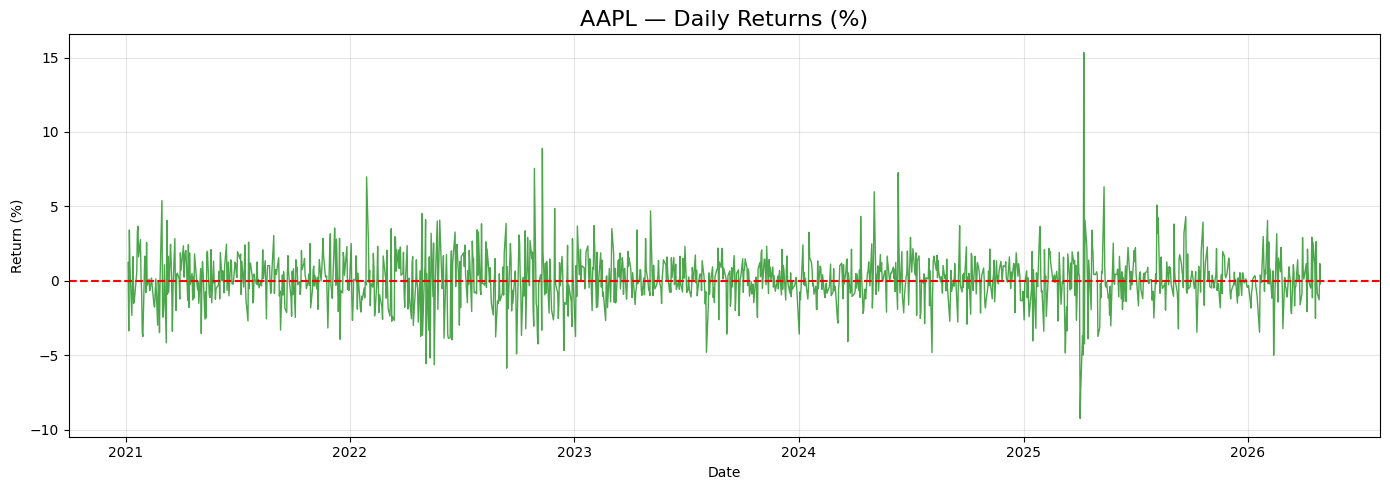

 Average daily return: 0.072%
 Best single day: 15.33%
 Worst single day: -9.25%


In [14]:
# -----------------------------------------------
# Daily Return = how much % the price changed each day
# Formula: (today's price - yesterday's price) / yesterday's price
# -----------------------------------------------

df["Daily Return"] = df["Close"].pct_change() * 100
# pct_change() calculates percentage change
# * 100 converts to percentage

plt.figure(figsize=(14, 5))

plt.plot(df.index,
         df["Daily Return"],
         color="green",
         alpha=0.7,
         linewidth=1)

plt.axhline(y=0, color="red", linestyle="--")  # zero line
plt.title(f"{ticker} — Daily Returns (%)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f" Average daily return: {df['Daily Return'].mean():.3f}%")
print(f" Best single day: {df['Daily Return'].max():.2f}%")
print(f" Worst single day: {df['Daily Return'].min():.2f}%")

***Chart 4 — Distribution of Returns***

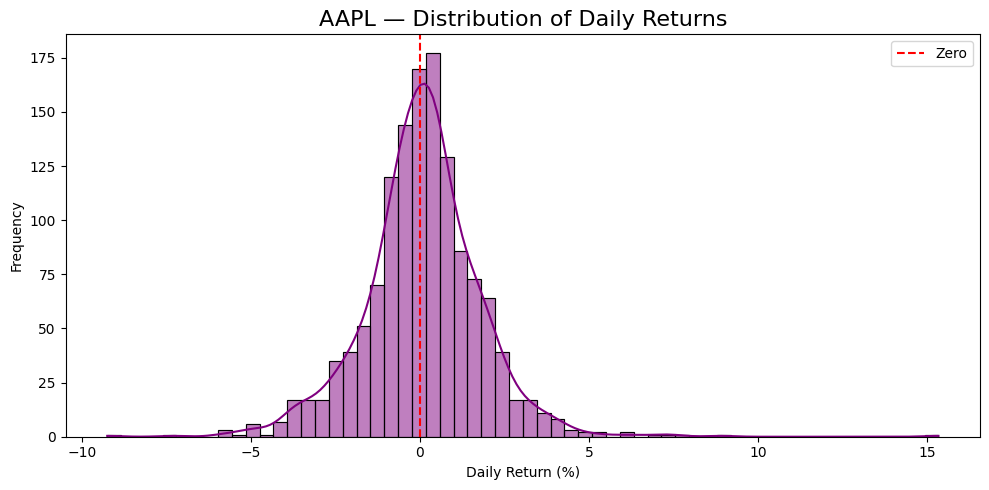

In [15]:
# -----------------------------------------------
# This shows how often the stock goes up vs down
# Bell curve shape = normal behavior
# -----------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(df["Daily Return"].dropna(),
             bins=60,
             color="purple",
             kde=True)   # kde=True draws a smooth curve on top

plt.title(f"{ticker} — Distribution of Daily Returns", fontsize=16)
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.axvline(x=0, color="red", linestyle="--", label="Zero")
plt.legend()
plt.tight_layout()
plt.show()

# **STEP 7 — Technical Indicators**

***Indicator 1 — Moving Averages (SMA)***

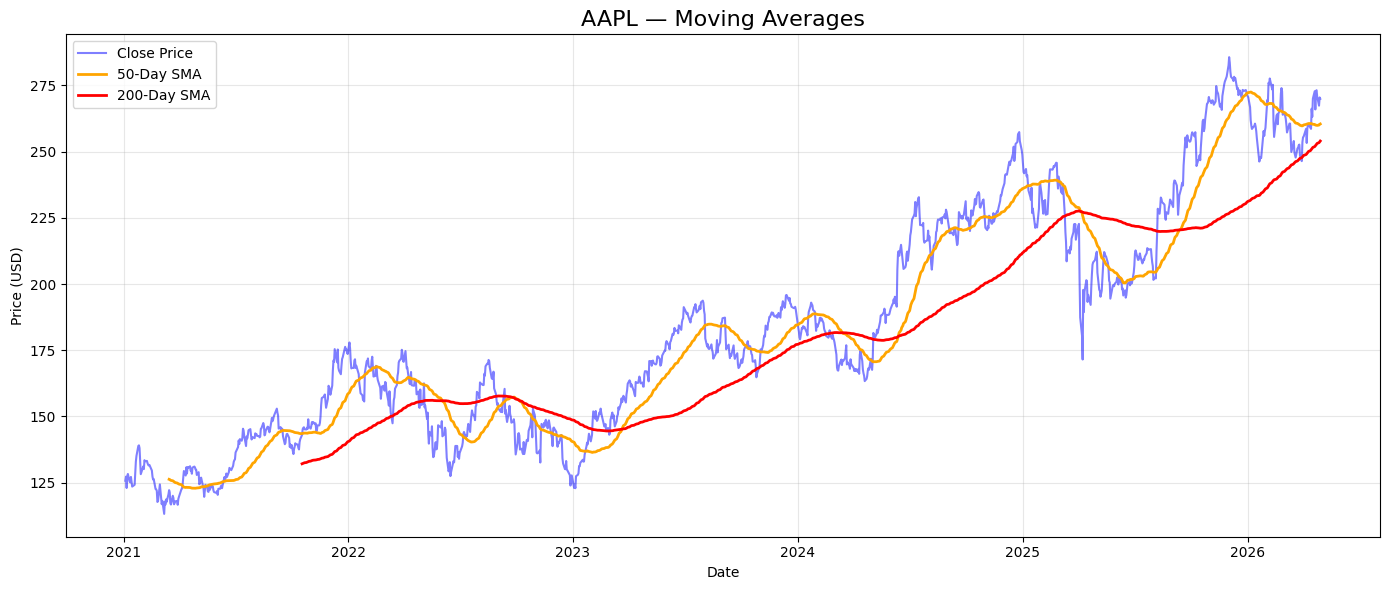

 When orange line crosses red line upward = BUY signal
 When orange line crosses red line downward = SELL signal


In [16]:
# -----------------------------------------------
# SMA = Simple Moving Average
# SMA_50 = average of last 50 days closing prices
# SMA_200 = average of last 200 days closing prices

# TRADING SIGNAL:
# When SMA_50 crosses ABOVE SMA_200 → BUY signal (Golden Cross)
# When SMA_50 crosses BELOW SMA_200 → SELL signal (Death Cross)
# -----------------------------------------------

df["SMA_50"] = df["Close"].rolling(window=50).mean()
df["SMA_200"] = df["Close"].rolling(window=200).mean()

plt.figure(figsize=(14, 6))

plt.plot(df["Close"], label="Close Price", alpha=0.5, color="blue")
plt.plot(df["SMA_50"], label="50-Day SMA", color="orange", linewidth=2)
plt.plot(df["SMA_200"], label="200-Day SMA", color="red", linewidth=2)

plt.title(f"{ticker} — Moving Averages", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(" When orange line crosses red line upward = BUY signal")
print(" When orange line crosses red line downward = SELL signal")

***Indicator 2 — RSI (Relative Strength Index)***

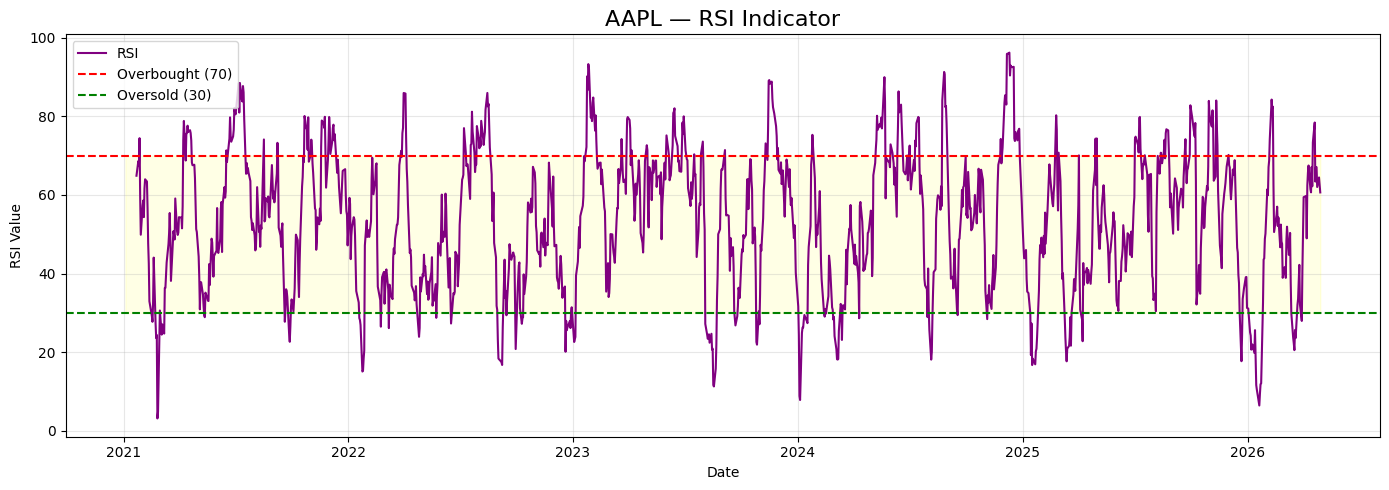

In [17]:
# -----------------------------------------------
# RSI measures if a stock is overbought or oversold
# RSI > 70 → Stock is OVERBOUGHT → Price may fall soon
# RSI < 30 → Stock is OVERSOLD → Price may rise soon
# RSI between 30-70 → Normal zone
# -----------------------------------------------

def calculate_rsi(series, period=14):
    # Calculate daily price changes
    delta = series.diff()

    # Separate gains (positive changes) and losses (negative changes)
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    # Calculate average gain and loss over the period
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()

    # RS = Relative Strength
    rs = avg_gain / avg_loss

    # RSI formula
    rsi = 100 - (100 / (1 + rs))
    return rsi

df["RSI"] = calculate_rsi(df["Close"])

plt.figure(figsize=(14, 5))

plt.plot(df.index, df["RSI"], color="purple", linewidth=1.5, label="RSI")
plt.axhline(70, color="red", linestyle="--", linewidth=1.5, label="Overbought (70)")
plt.axhline(30, color="green", linestyle="--", linewidth=1.5, label="Oversold (30)")
plt.fill_between(df.index, 30, 70, alpha=0.1, color="yellow")

plt.title(f"{ticker} — RSI Indicator", fontsize=16)
plt.xlabel("Date")
plt.ylabel("RSI Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

***Indicator 3 — Bollinger Bands***

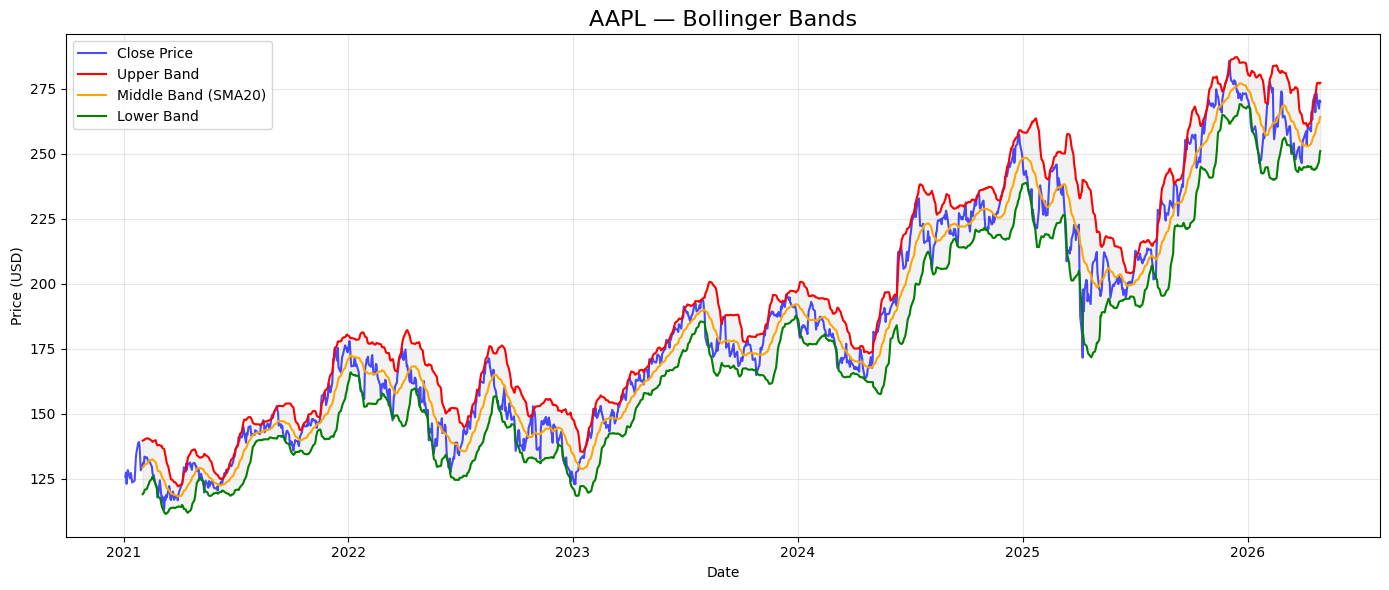

In [18]:
# -----------------------------------------------
# Bollinger Bands show price volatility
# Upper Band = average + 2 standard deviations
# Lower Band = average - 2 standard deviations
# When price touches UPPER band → may be overbought
# When price touches LOWER band → may be oversold
# -----------------------------------------------

df["BB_Mid"] = df["Close"].rolling(window=20).mean()
df["BB_Std"] = df["Close"].rolling(window=20).std()
df["BB_Upper"] = df["BB_Mid"] + (2 * df["BB_Std"])
df["BB_Lower"] = df["BB_Mid"] - (2 * df["BB_Std"])

plt.figure(figsize=(14, 6))

plt.plot(df["Close"], label="Close Price", color="blue", alpha=0.7)
plt.plot(df["BB_Upper"], label="Upper Band", color="red", linewidth=1.5)
plt.plot(df["BB_Mid"], label="Middle Band (SMA20)", color="orange", linewidth=1.5)
plt.plot(df["BB_Lower"], label="Lower Band", color="green", linewidth=1.5)
plt.fill_between(df.index, df["BB_Lower"], df["BB_Upper"],
                 alpha=0.1, color="gray")

plt.title(f"{ticker} — Bollinger Bands", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

***Indicator 4 — MACD***

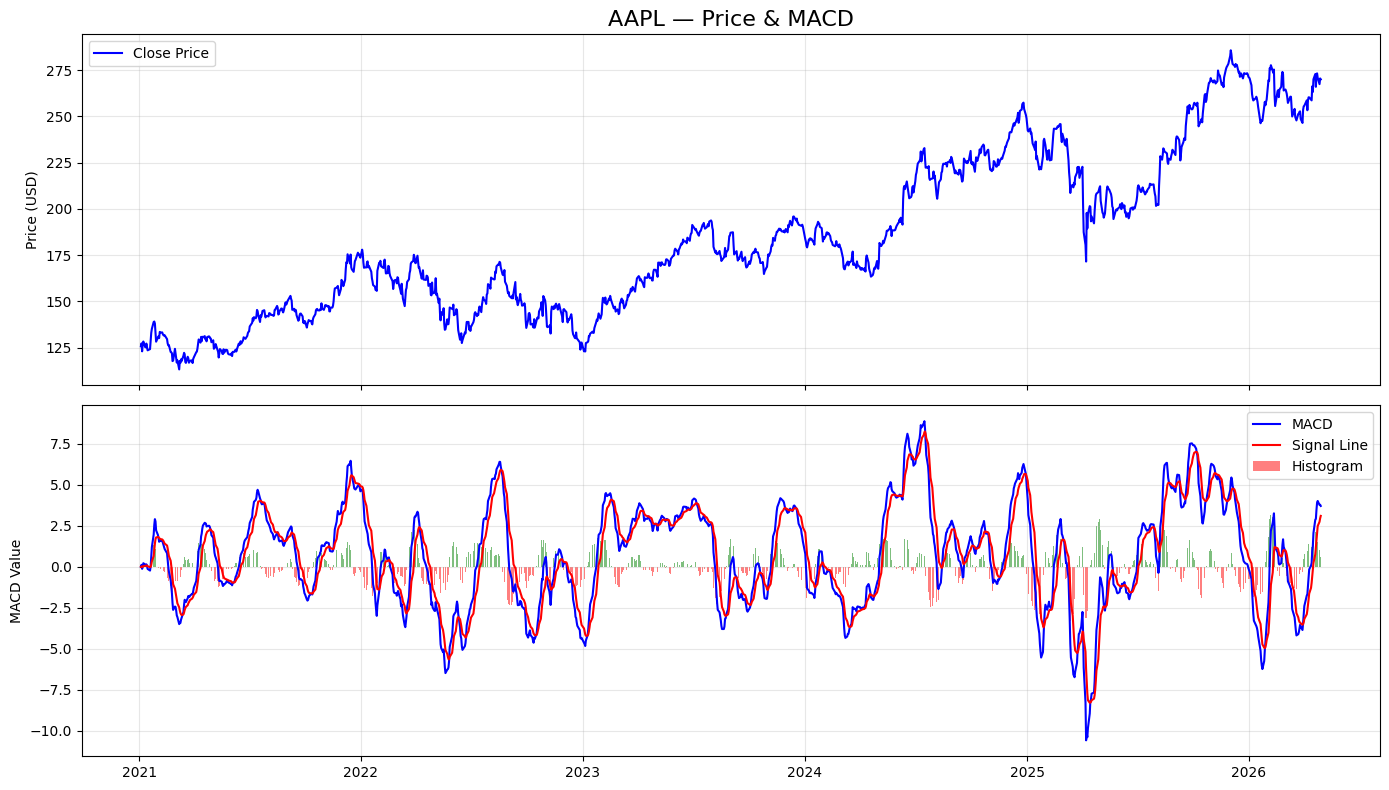

In [19]:
# -----------------------------------------------
# MACD = Moving Average Convergence Divergence
# It shows momentum — is the stock gaining or losing speed?
# When MACD crosses ABOVE Signal line → BUY
# When MACD crosses BELOW Signal line → SELL
# -----------------------------------------------

df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"] = df["EMA_12"] - df["EMA_26"]
df["Signal_Line"] = df["MACD"].ewm(span=9, adjust=False).mean()
df["MACD_Histogram"] = df["MACD"] - df["Signal_Line"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top chart = closing price
ax1.plot(df["Close"], color="blue", label="Close Price")
ax1.set_title(f"{ticker} — Price & MACD", fontsize=16)
ax1.set_ylabel("Price (USD)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom chart = MACD
ax2.plot(df["MACD"], label="MACD", color="blue", linewidth=1.5)
ax2.plot(df["Signal_Line"], label="Signal Line", color="red", linewidth=1.5)
ax2.bar(df.index, df["MACD_Histogram"],
        color=["green" if x > 0 else "red" for x in df["MACD_Histogram"]],
        alpha=0.5, label="Histogram")
ax2.set_ylabel("MACD Value")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **STEP 8 — Compare Multiple Stocks**

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


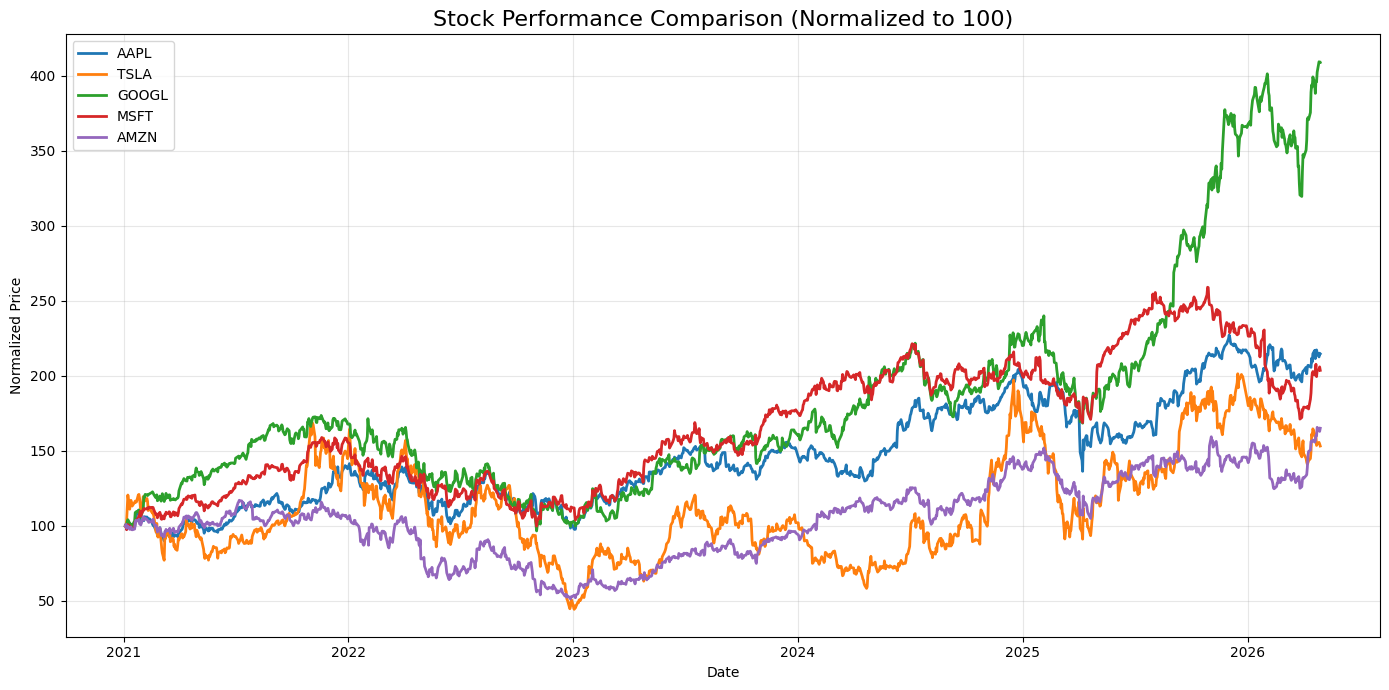

📌 Stock that grew the most:
GOOGL    408.813049
AAPL     214.664794
MSFT     203.669236
AMZN     165.089774
TSLA     153.253759
Name: 2026-04-29 00:00:00, dtype: float64


In [73]:
# -----------------------------------------------
# Compare how different stocks performed
# We normalize prices so all start at 100
# This makes comparison fair regardless of price
# -----------------------------------------------

stocks = ["AAPL", "TSLA", "GOOGL", "MSFT", "AMZN"]
all_data = {}

for stock in stocks:
    data = yf.download(stock, start="2021-01-01", end="2026-04-30")

    # Flatten multi-level columns if present
    # Based on previous `df` output, the column names have a 'Price' level (level 0)
    # and the actual metric names ('Close', 'High', etc.) are also in level 0.
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0) # Get 'Close', 'High', 'Low' etc. labels

    all_data[stock] = data["Close"]

# Combine into one DataFrame
combined = pd.DataFrame(all_data)
combined = combined.dropna()

# Normalize — divide everything by first row × 100
normalized = (combined / combined.iloc[0]) * 100

plt.figure(figsize=(14, 7))

for stock in stocks:
    plt.plot(normalized.index, normalized[stock], label=stock, linewidth=2)

plt.title("Stock Performance Comparison (Normalized to 100)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("📌 Stock that grew the most:")
print(normalized.iloc[-1].sort_values(ascending=False))

# **STEP 9 — Forecast Future Prices with Prophet**

In [26]:
# -----------------------------------------------
# Prophet is a forecasting tool made by Facebook
# It learns patterns from past data and predicts future
# -----------------------------------------------

from prophet import Prophet

# Prepare data in Prophet format
# Prophet needs columns named exactly "ds" and "y"
prophet_df = df.reset_index()[["Date", "Close"]].copy()
prophet_df.columns = ["ds", "y"]   # rename columns
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

print("Prophet input data format:")
print(prophet_df.head())

# Create and train the model
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05  # controls how flexible the trend is
)

model.fit(prophet_df)
print(" Model trained successfully!")

# Create future dates — forecast 90 days ahead
future = model.make_future_dataframe(periods=90)

# Generate forecast
forecast = model.predict(future)

print("\nForecast columns:")
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10))

Prophet input data format:
          ds           y
0 2021-01-04  207.956116
1 2021-01-05  208.156708
2 2021-01-06  202.759399
3 2021-01-07  208.529297
4 2021-01-08  209.799835
 Model trained successfully!

Forecast columns:
             ds        yhat  yhat_lower  yhat_upper
1416 2026-07-19  462.283532  433.660256  490.225471
1417 2026-07-20  486.646855  457.579896  515.297327
1418 2026-07-21  486.285787  459.203948  515.967294
1419 2026-07-22  486.690064  457.758799  513.761814
1420 2026-07-23  486.167012  458.144193  515.647992
1421 2026-07-24  486.513414  456.935909  514.162240
1422 2026-07-25  462.280720  432.836602  492.331269
1423 2026-07-26  462.329272  433.455787  491.227404
1424 2026-07-27  486.779752  459.169594  515.867640
1425 2026-07-28  486.522939  455.894828  516.632795


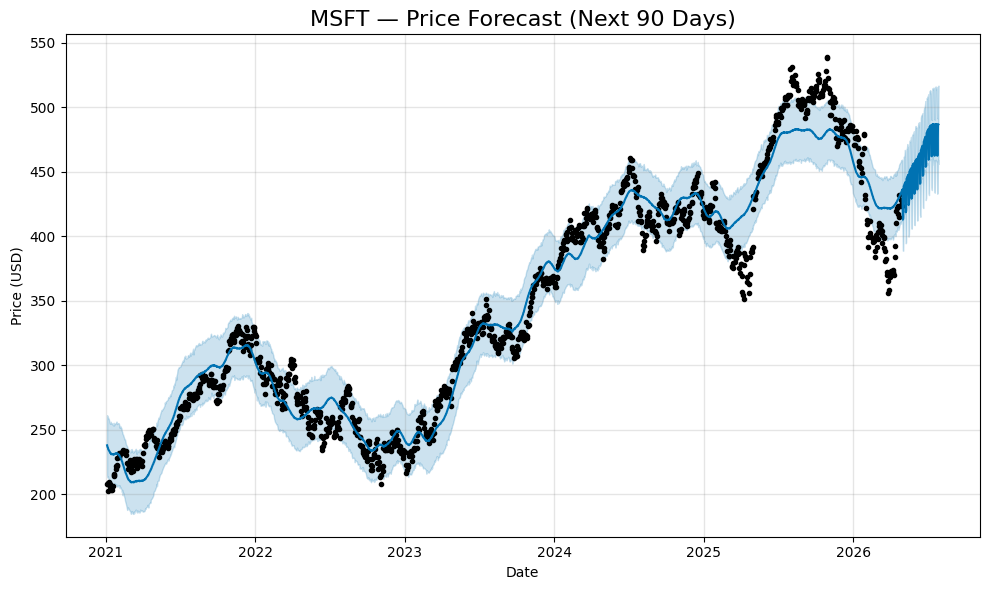

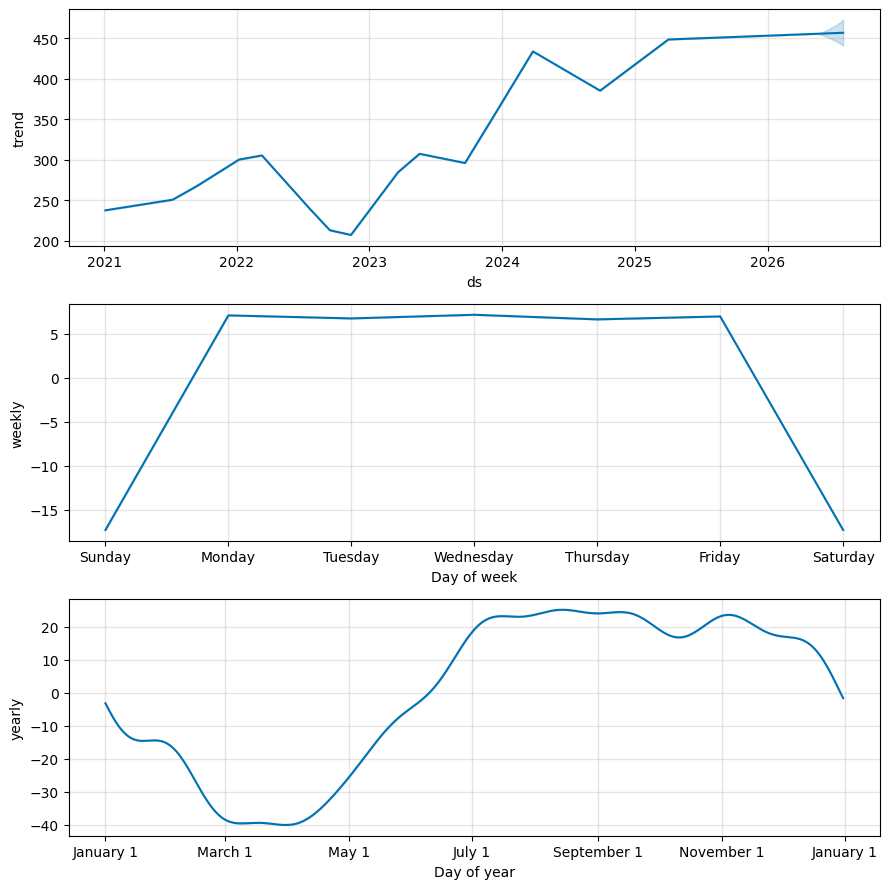

 Blue line = predicted price
 Shaded area = uncertainty range (could be higher or lower)


In [27]:
# -----------------------------------------------
# Plot the forecast
# -----------------------------------------------

fig1 = model.plot(forecast)
plt.title(f"{ticker} — Price Forecast (Next 90 Days)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

# Plot forecast components (trend, weekly, yearly patterns)
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()

print(" Blue line = predicted price")
print(" Shaded area = uncertainty range (could be higher or lower)")

# **STEP 10 — Sentiment Analysis**

In [28]:
# -----------------------------------------------
# Sentiment Analysis = understanding the mood of text
# We check if news headlines are positive or negative
# This tells us if market mood is good or bad
# -----------------------------------------------

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Create analyzer
analyzer = SentimentIntensityAnalyzer()

# Sample headlines (in real project, fetch from NewsAPI)
headlines = [
    "Apple reports record-breaking quarterly profits",
    "Apple stock crashes after disappointing iPhone sales",
    "Apple announces revolutionary new AI features",
    "Investors worried about Apple supply chain issues",
    "Apple becomes most valuable company in history",
    "Apple faces major lawsuit over App Store policies",
    "Strong demand for Apple products boosts stock price",
    "Apple cuts production amid weak consumer demand"
]

# Analyze each headline
results = []
for headline in headlines:
    scores = analyzer.polarity_scores(headline)
    # compound score ranges from -1 (very negative) to +1 (very positive)
    sentiment = "POSITIVE " if scores["compound"] > 0.05 else \
                "NEGATIVE " if scores["compound"] < -0.05 else \
                "NEUTRAL "

    results.append({
        "Headline": headline[:50] + "...",
        "Compound Score": round(scores["compound"], 3),
        "Sentiment": sentiment
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                                             Headline  Compound Score Sentiment
   Apple reports record-breaking quarterly profits...           0.440 POSITIVE 
Apple stock crashes after disappointing iPhone sal...          -0.494 NEGATIVE 
     Apple announces revolutionary new AI features...           0.000  NEUTRAL 
 Investors worried about Apple supply chain issues...          -0.296 NEGATIVE 
    Apple becomes most valuable company in history...           0.526 POSITIVE 
 Apple faces major lawsuit over App Store policies...          -0.294 NEGATIVE 
Strong demand for Apple products boosts stock pric...           0.625 POSITIVE 
   Apple cuts production amid weak consumer demand...          -0.681 NEGATIVE 


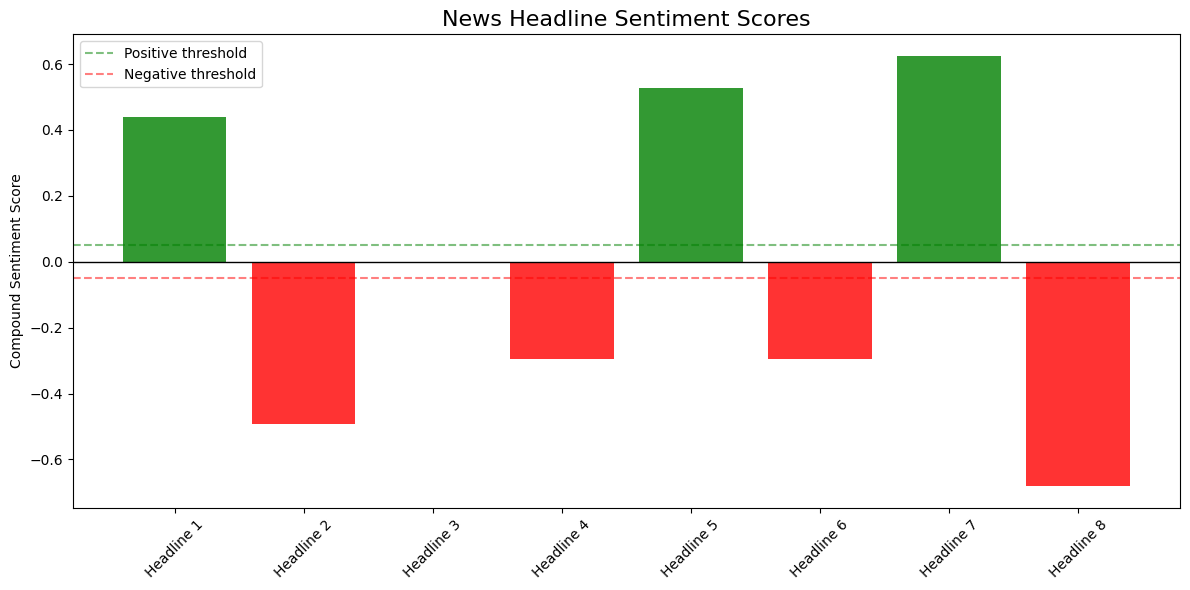

In [29]:
# -----------------------------------------------
# Visualize sentiment scores
# -----------------------------------------------

plt.figure(figsize=(12, 6))

colors = ["green" if s > 0.05 else "red" if s < -0.05 else "yellow"
          for s in results_df["Compound Score"]]

bars = plt.bar(range(len(results_df)),
               results_df["Compound Score"],
               color=colors,
               alpha=0.8)

plt.axhline(y=0, color="black", linewidth=1)
plt.axhline(y=0.05, color="green", linestyle="--", alpha=0.5, label="Positive threshold")
plt.axhline(y=-0.05, color="red", linestyle="--", alpha=0.5, label="Negative threshold")

plt.title("News Headline Sentiment Scores", fontsize=16)
plt.ylabel("Compound Sentiment Score")
plt.xticks(range(len(results_df)),
           [f"Headline {i+1}" for i in range(len(results_df))],
           rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# **STEP 11 — Correlation Heatmap**

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


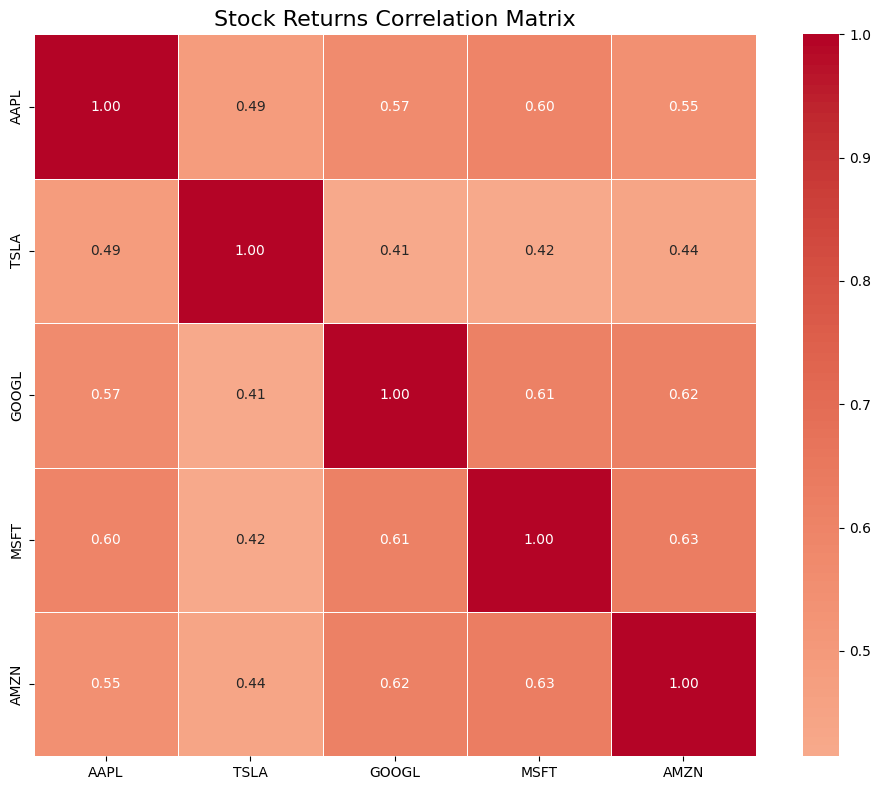

 High correlation = stocks move similarly
 Low correlation = stocks are independent


In [32]:
# -----------------------------------------------
# Correlation = how related are two things?
# +1 = they move together perfectly
# -1 = they move in opposite directions
#  0 = no relationship
# -----------------------------------------------

stocks = ["AAPL", "TSLA", "GOOGL", "MSFT", "AMZN"]
close_prices = pd.DataFrame()

for stock in stocks:
    data = yf.download(stock, start="2021-01-01", end="2026-04-30")
    close_prices[stock] = data["Close"]

# Calculate correlation
correlation = close_prices.pct_change().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation,
            annot=True,          # show numbers inside boxes
            fmt=".2f",           # 2 decimal places
            cmap="coolwarm",     # color scheme
            center=0,
            square=True,
            linewidths=0.5)

plt.title("Stock Returns Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

print(" High correlation = stocks move similarly")
print(" Low correlation = stocks are independent")

# **STEP 12 — Interactive Dashboard with Plotly**

In [39]:
# -----------------------------------------------
# Plotly makes charts you can zoom, hover, click
# Much better than matplotlib for presenting
# -----------------------------------------------

from plotly.subplots import make_subplots
import plotly.graph_objects as go
import pandas as pd # Ensure pandas is imported as it's used for df manipulation
import yfinance as yf # Ensure yfinance is imported for data download

# Re-initialize df with AAPL data and calculate indicators for this dashboard
ticker = "AAPL"
df = yf.download(ticker, start="2021-01-01", end="2026-04-30")

# Flatten multi-level columns if present (from data cleaning step d7cayqYEj3ED)
# yfinance can sometimes return a MultiIndex, so this ensures it's flat.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Make sure Date column is in date format and set as index
df = df.reset_index()
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")
df = df.dropna() # Drop any rows with NaN values that might have appeared after index reset

# Re-calculate SMA (from HkJ7oc09qanx)
df["SMA_50"] = df["Close"].rolling(window=50).mean()
df["SMA_200"] = df["Close"].rolling(window=200).mean()

# Re-calculate RSI (from 1oEmgqrAqaqh)
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi
df["RSI"] = calculate_rsi(df["Close"])

# Re-calculate MACD (from -oX2PLGDqawI)
df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"] = df["EMA_12"] - df["EMA_26"]
df["Signal_Line"] = df["MACD"].ewm(span=9, adjust=False).mean()
# MACD_Histogram is not used in the plot, but calculated for completeness if needed
df["MACD_Histogram"] = df["MACD"] - df["Signal_Line"]

# Drop NaN values that result from rolling window calculations for indicators
df = df.dropna()

# Create a dashboard with 4 charts
fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=("Closing Price & Moving Averages",
                    "Volume",
                    "RSI",
                    "MACD")
)

# Chart 1 — Price + Moving Averages
fig.add_trace(go.Scatter(x=df.index, y=df["Close"],
                          name="Close Price", line=dict(color="blue")), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["SMA_50"],
                          name="SMA 50", line=dict(color="orange")), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["SMA_200"],
                          name="SMA 200", line=dict(color="red")), row=1, col=1)

# Chart 2 — Volume
fig.add_trace(go.Bar(x=df.index, y=df["Volume"],
                      name="Volume", marker_color="purple"), row=2, col=1)

# Chart 3 — RSI
fig.add_trace(go.Scatter(x=df.index, y=df["RSI"],
                          name="RSI", line=dict(color="purple")), row=3, col=1)
fig.add_hline(y=70, line_dash="dash", line_color="red", row=3, col=1)
fig.add_hline(y=30, line_dash="dash", line_color="green", row=3, col=1)

# Chart 4 — MACD
fig.add_trace(go.Scatter(x=df.index, y=df["MACD"],
                          name="MACD", line=dict(color="blue")), row=4, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["Signal_Line"],
                          name="Signal", line=dict(color="red")), row=4, col=1)

# Update layout
fig.update_layout(
    height=1000,
    title_text=f"{ticker} Complete Stock Analysis Dashboard",
    showlegend=True,
    xaxis_rangeslider_visible=False
)

fig.show()
print(" You can zoom, hover, and interact with this chart!")

[*********************100%***********************]  1 of 1 completed


 You can zoom, hover, and interact with this chart!


# **STEP 13 — Final Report**

In [77]:
# -----------------------------------------------
# Print a professional summary of your analysis
# -----------------------------------------------

print("=" * 60)
print(f"       STOCK ANALYSIS REPORT — {ticker}")
print("=" * 60)
print(f"\n Analysis Period: 2021-01-01 to 2026-04-30")
print(f"📦 Total trading days: {len(df)}")

print(f"\n💰 PRICE SUMMARY:")
print(f"   Starting Price : ${df['Close'].iloc[0]:.2f}")
print(f"   Ending Price   : ${df['Close'].iloc[-1]:.2f}")
print(f"   Highest Price  : ${df['High'].max():.2f}")
print(f"   Lowest Price   : ${df['Low'].min():.2f}")

# Re-calculate Daily Return for the summary report as df was modified
df["Daily Return"] = df["Close"].pct_change() * 100

total_return = ((df['Close'].iloc[-1] - df['Close'].iloc[0]) / df['Close'].iloc[0]) * 100
print(f"\n PERFORMANCE:")
print(f"   Total Return   : {total_return:.2f}%")
print(f"   Avg Daily Return: {df['Daily Return'].mean():.3f}%")
print(f"   Volatility (Std): {df['Daily Return'].std():.3f}%")

# --- Re-calculate RSI for the report to ensure it's present ---
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period, min_periods=1).mean()
    avg_loss = loss.rolling(window=period, min_periods=1).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df["RSI"] = calculate_rsi(df["Close"])
# ----------------------------------------------------------------

current_rsi = df["RSI"].iloc[-1]
print(f"\n TECHNICAL INDICATORS (Latest):")
print(f"   RSI            : {current_rsi:.2f}")
if current_rsi > 70:
    print(f"   RSI Signal     :  OVERBOUGHT — Price may fall")
elif current_rsi < 30:
    print(f"   RSI Signal     :  OVERSOLD — Price may rise")
else:
    print(f"   RSI Signal     :  NEUTRAL")

print(f"\n🔮 FORECAST:")
last_forecast = forecast.tail(1).iloc[0]
print(f"   90-Day Prediction : ${last_forecast['yhat']:.2f}")
print(f"   Lower Estimate    : ${last_forecast['yhat_lower']:.2f}")
print(f"   Upper Estimate    : ${last_forecast['yhat_upper']:.2f}")

print("\n" + "=" * 60)
print(" Analysis Complete!")
print("=" * 60)

       STOCK ANALYSIS REPORT — AAPL

 Analysis Period: 2021-01-01 to 2026-04-30
📦 Total trading days: 1336

💰 PRICE SUMMARY:
   Starting Price : $125.74
   Ending Price   : $269.92
   Highest Price  : $288.08
   Lowest Price   : $113.08

 PERFORMANCE:
   Total Return   : 114.66%
   Avg Daily Return: 0.072%
   Volatility (Std): 1.744%

 TECHNICAL INDICATORS (Latest):
   RSI            : 60.63
   RSI Signal     :  NEUTRAL

🔮 FORECAST:
   90-Day Prediction : $486.52
   Lower Estimate    : $455.89
   Upper Estimate    : $516.63

 Analysis Complete!
